# Artificial Neural Networks

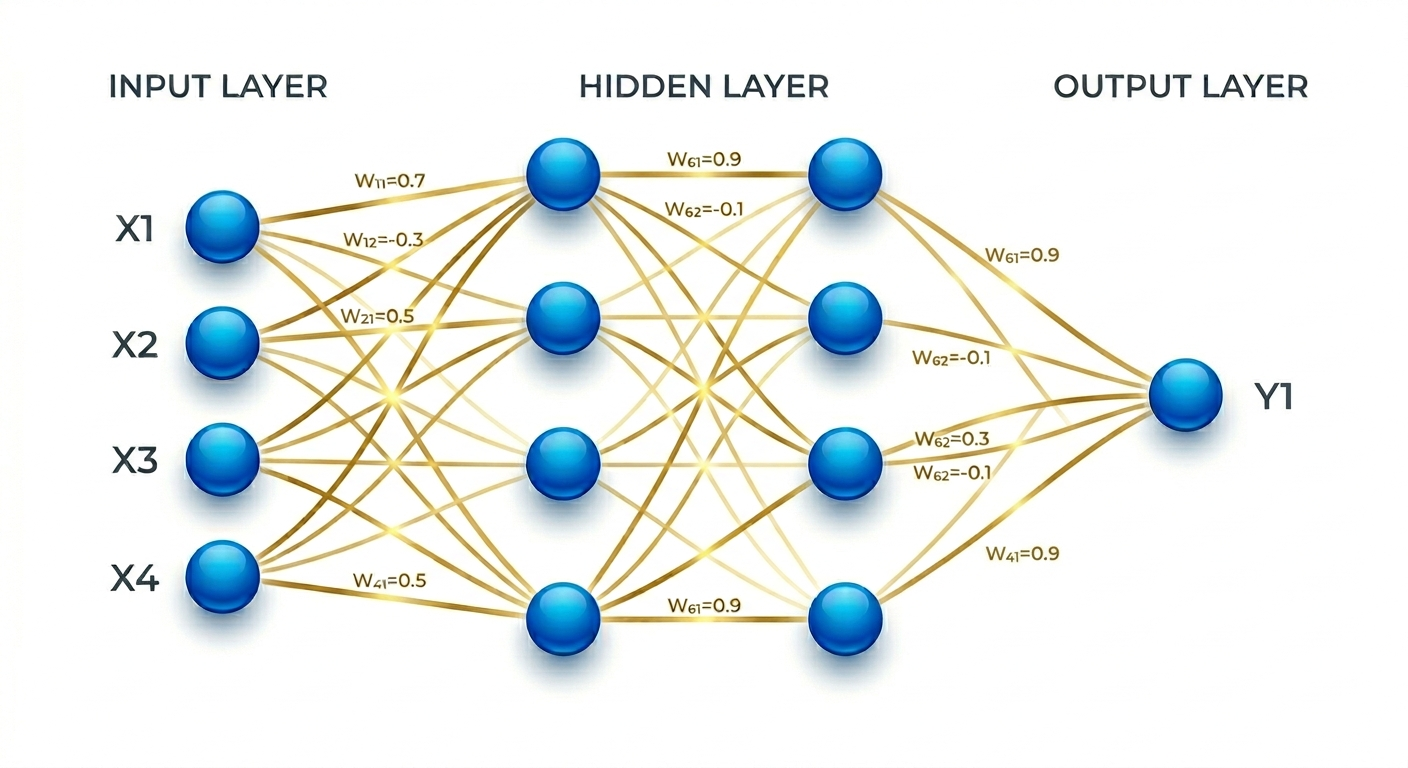

An Artificial Neural Network (ANN) is a computational model inspired by the biological neurons in the human brain. It consists of interconnected layers of "nodes", input, hidden, and output that process data through weighted connections.

By adjusting these weights based on error during training, the network learns to recognize complex patterns and make predictions, powering modern AI tasks like image recognition and natural language processing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

Load the data

In [3]:
df = pd.read_csv('data.csv')

Preprocessing

In [4]:
X = df['Sentence'].values
y = df['Sentiment'].values

Encode the labels

In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

Split into training and testing sets

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

TF-IDF Vectorization

In [7]:
# Limit to 5000 features to keep the ANN input manageable

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = tfidf.fit_transform(X_train_raw).toarray()
X_test = tfidf.transform(X_test_raw).toarray()

Build the ANN Architecture

In [8]:
model = Sequential([
    # Input Layer (matching TF-IDF feature count)
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3), # Prevents overfitting

    # Hidden Layer
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Optimization: Use Adam with a defined learning rate

In [13]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Train the model

In [16]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9315 - loss: 0.0854 - val_accuracy: 0.6225 - val_loss: 3.0380
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9369 - loss: 0.0853 - val_accuracy: 0.6193 - val_loss: 2.9637
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9371 - loss: 0.0858 - val_accuracy: 0.6246 - val_loss: 3.0533
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9379 - loss: 0.0847 - val_accuracy: 0.6235 - val_loss: 3.2206
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9390 - loss: 0.0838 - val_accuracy: 0.6235 - val_loss: 3.1283
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9403 - loss: 0.0843 - val_accuracy: 0.6203 - val_loss: 3.2708
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9347 - loss: 0.0851 - val_accuracy: 0.6160 - val_loss: 3.1285
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9350 - loss: 0.0859 - val_accu

Evaluation

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Optimized Test Accuracy: {test_acc:.2f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6527 - loss: 2.9507
Optimized Test Accuracy: 0.65
